# Airbnb Tokyo Price Prediction with TabPFN Regression

`notebook/airbnb_LightGBM_2.ipynb` と同じ Airbnb Tokyo データ、特徴量、サンプル抽出条件を使い、`notebook/test_TabPFN_regress.ipynb` と同様に TabPFN の回帰モデルで $\log(\mathrm{price})$ を予測する。

In [19]:
!pip install -q tabpfn

In [20]:
# 必要なライブラリが未インストールの場合のみコメントを外してください。
# %pip install -q -U tabpfn scikit-learn seaborn


In [21]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

sns.set_theme(style="whitegrid")
SEED = 42


## 1. データの読み込み

`airbnb_LightGBM_2.ipynb` と同じ候補パスを確認し、ローカルに加工済み CSV がなければ Inside Airbnb の listings データを読み込む。

In [ ]:
DATA_URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2026-06-30/data/listings.csv.gz"
filename = "airbnb_tokyo_model_ready_eda.csv"
candidate_paths = [Path(filename), Path("data") / filename, Path("notebook") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

numeric_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "host_listings_count",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_is_superhost",
    "instant_bookable",
]

if csv_path is not None:
    df = pd.read_csv(csv_path)
    print(f"Loaded local modeling data: {csv_path.resolve()}")
else:
    selected_cols = ["price"] + numeric_features + categorical_features
    raw = pd.read_csv(DATA_URL, compression="gzip", low_memory=False)
    available_cols = [col for col in selected_cols if col in raw.columns]
    df = raw[available_cols].copy()
    print(f"Loaded Inside Airbnb data from: {DATA_URL}")

print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())


## 2. 説明変数と目的変数の作成

`number_of_reviews >= 5` の listing に絞り、そのサンプル内で `price_num` の下位0.1%と上位0.1%を除外する。TabPFN の計算時間を調整するため、`TABPFN_SAMPLE_SIZE` で使用する行数を指定する。目的変数は $\log(\mathrm{price})$ とする。


In [ ]:
TABPFN_SAMPLE_SIZE = 1_000  # 全件使う場合は None にする


def clean_price(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    x = re.sub(r"[^0-9.]", "", str(x))
    return float(x) if x else np.nan

if "price_num" not in df.columns:
    if "price" not in df.columns:
        raise KeyError("`price_num` または `price` が必要です。")
    df["price_num"] = df["price"].apply(clean_price)

available_numeric_features = [col for col in numeric_features if col in df.columns]
available_categorical_features = [col for col in categorical_features if col in df.columns]
feature_columns = available_numeric_features + available_categorical_features

if "number_of_reviews" not in df.columns:
    raise KeyError("`number_of_reviews` が必要です。")
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")

base_mask = (
    df["price_num"].notna()
    & (df["price_num"] > 0)
    & df["number_of_reviews"].notna()
    & (df["number_of_reviews"] >= 5)
)
price_lower = df.loc[base_mask, "price_num"].quantile(0.001)
price_upper = df.loc[base_mask, "price_num"].quantile(0.999)
sample_mask = base_mask & df["price_num"].between(price_lower, price_upper)

filtered_data = df.loc[
    sample_mask,
    feature_columns + ["price_num"],
].copy()

if TABPFN_SAMPLE_SIZE is not None:
    if TABPFN_SAMPLE_SIZE <= 0:
        raise ValueError("TABPFN_SAMPLE_SIZE は正の整数、または None を指定してください。")
    sample_size = min(TABPFN_SAMPLE_SIZE, len(filtered_data))
    model_data = filtered_data.sample(n=sample_size, random_state=SEED).reset_index(drop=True)
else:
    model_data = filtered_data.reset_index(drop=True)

print(f"Rows with positive price and number_of_reviews >= 5: {base_mask.sum():,}")
print(f"Price filter: {price_lower:,.0f} <= price_num <= {price_upper:,.0f}")
print(f"Rows after price 0.1% tail filtering: {len(filtered_data):,}")
print(f"TABPFN_SAMPLE_SIZE: {TABPFN_SAMPLE_SIZE}")
print(f"Rows used for modeling: {len(model_data):,}")

for column in available_numeric_features:
    model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

for column in available_categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype(str)

X = model_data[feature_columns]
y = np.log(model_data["price_num"]).astype("float32")

print(f"Numeric features: {available_numeric_features}")
print(f"Categorical features: {available_categorical_features}")
display(X.head())
display(y.describe().rename("log_price").to_frame())


## 3. データ分割と前処理

TabPFN には数値行列を渡す。数値列は中央値補完、カテゴリ列は未知カテゴリを `-1` とする ordinal encoding で変換する。train / validation / test の分割は `airbnb_LightGBM_2.ipynb` と同じ比率・乱数シードにする。

In [24]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.5, random_state=SEED
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), available_numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
                (
                    "encoder",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                ),
            ]),
            available_categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_tabpfn = preprocessor.fit_transform(X_train).astype("float32")
X_valid_tabpfn = preprocessor.transform(X_valid).astype("float32")
X_test_tabpfn = preprocessor.transform(X_test).astype("float32")

print(f"Train: {len(X_train):,}, validation: {len(X_valid):,}, test: {len(X_test):,}")
print(f"TabPFN feature matrix: {X_train_tabpfn.shape[0]:,} rows x {X_train_tabpfn.shape[1]:,} columns")


Train: 800, validation: 100, test: 100
TabPFN feature matrix: 800 rows x 18 columns


## 4. TabPFN の学習

ログインやアカウント認証が不要な Version 2 を使う `TabPFNRegressor.create_default_for_version(ModelVersion.V2)`

Version 3 を試してもよい

In [25]:
reg = TabPFNRegressor.create_default_for_version(ModelVersion.V2)

reg.fit(X_train_tabpfn, y_train.to_numpy())
valid_pred = reg.predict(X_valid_tabpfn)
y_pred = reg.predict(X_test_tabpfn)

linear_reg = LinearRegression()
linear_reg.fit(X_train_tabpfn, y_train)
linear_valid_pred = linear_reg.predict(X_valid_tabpfn)
linear_test_pred = linear_reg.predict(X_test_tabpfn)


/usr/local/lib/python3.12/dist-packages/tabpfn/validation.py:142: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  _validate_num_samples_for_cpu(


## 5. テストデータでの評価

TabPFN と線形回帰 baseline を比較する。

In [26]:
def regression_metrics(y_true, pred):
    return pd.Series({
        "RMSE (log price)": mean_squared_error(y_true, pred) ** 0.5,
        "MAE (log price)": mean_absolute_error(y_true, pred),
        "R2 (log price)": r2_score(y_true, pred),
        "MAE (price, JPY)": mean_absolute_error(np.exp(y_true), np.exp(pred)),
    })

metrics = pd.DataFrame({
    "TabPFN validation": regression_metrics(y_valid, valid_pred),
    "TabPFN test": regression_metrics(y_test, y_pred),
    "LinearRegression validation": regression_metrics(y_valid, linear_valid_pred),
    "LinearRegression test": regression_metrics(y_test, linear_test_pred),
})
display(metrics)


,TabPFN validation,TabPFN test,LinearRegression validation,LinearRegression test
RMSE (log price),0.388944,0.417478,0.437545,0.541018
MAE (log price),0.277765,0.282524,0.335510,0.400736
R2 (log price),0.608840,0.593959,0.504976,0.318093
"MAE (price, JPY)",8862.068359,8116.827637,10649.847656,10654.790039


### 予測値と残差の可視化

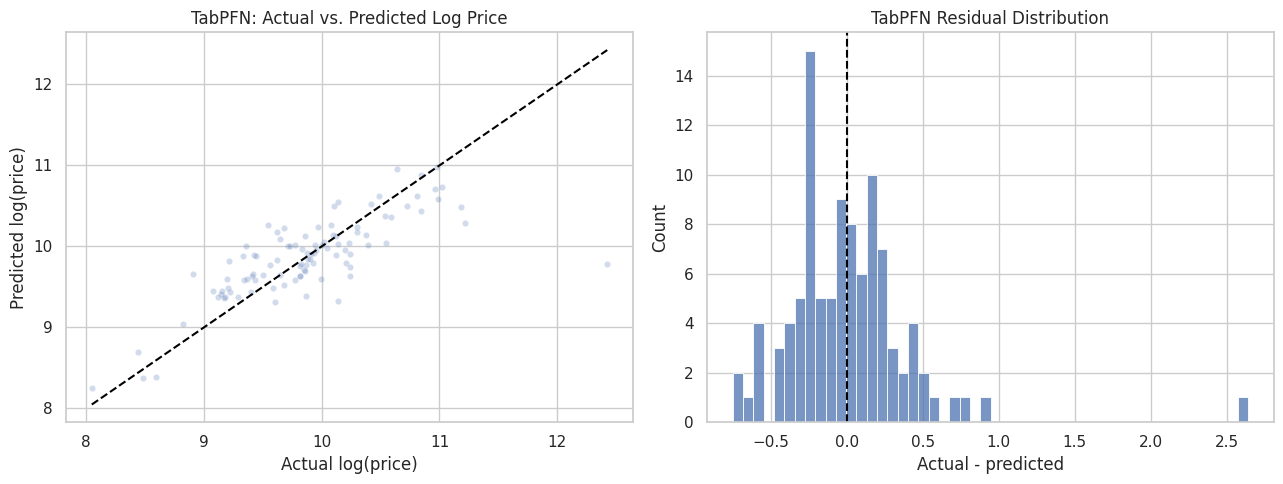

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="TabPFN: Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="TabPFN Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()


## 6. 予測結果の例

In [ ]:
prediction_examples = X_test.head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test.head(10))
prediction_examples["predicted_price_tabpfn"] = np.exp(reg.predict(X_test_tabpfn[:10]))
prediction_examples["predicted_price_linear"] = np.exp(linear_reg.predict(X_test_tabpfn[:10]))
display(prediction_examples)
